# Tahap 3 - Uji Integrasi Machine Learning dan Algoritma Genetika

**Problem 12: Manufaktur - Optimasi Penjadwalan Pemeliharaan Mesin**

Pada tahap ini kami menguji alur dari prediksi sisa umur 50 mesin sampai penyusunan urutan perbaikan dengan Algoritma Genetika.

Regresi kami gunakan untuk memperkirakan sisa umur mesin. Setelah itu, Algoritma Genetika menyusun antrean perbaikan berdasarkan sisa umur dan durasi perbaikan. Alur ini kami pilih karena proyek kami membutuhkan dua keputusan: memperkirakan kapan mesin berisiko rusak dan menentukan urutan kerja teknisi.

## 1. Alur Data dari Model ke Jadwal

Kami tetap menggunakan **Opsi A (Pra-Komputasi)**. Model Machine Learning dijalankan satu kali untuk menghasilkan prediksi sisa umur. Nilai tersebut kemudian digunakan oleh Algoritma Genetika untuk menilai setiap urutan jadwal.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import joblib

ROOT = Path(r'D:/tubes_ka')
TAHAP_1 = ROOT / 'tahap 1'
TAHAP_3 = ROOT / 'tahap 3'
MODEL_PATH = TAHAP_1 / 'models' / 'best_rul_model.joblib'
SOURCE_CSV = ROOT / 'ds12_manufaktur_maintenance.csv'
SIM50_PATH = TAHAP_1 / 'outputs' / 'data' / 'input_50_mesin_anomali_prediksi.csv'

FEATURES = [
    'jam_operasi_aktif', 'jenis_mesin', 'tekanan_oli_bar', 'suhu_c',
    'vibrasi_mm_s', 'shift_operator', 'kebisingan_lingkungan_db'
]

model = joblib.load(MODEL_PATH)
source_df = pd.read_csv(SOURCE_CSV)
sim50_ids = pd.read_csv(SIM50_PATH)['id_log_sensor'].tolist()
ml_input = source_df[source_df['id_log_sensor'].isin(sim50_ids)].copy()
ml_input['order_ref'] = ml_input['id_log_sensor'].map({mid: i for i, mid in enumerate(sim50_ids)})
ml_input = ml_input.sort_values('order_ref').drop(columns=['order_ref']).reset_index(drop=True)

predicted_rul = model.predict(ml_input[FEATURES])
print('Input ML shape:', ml_input[FEATURES].shape)
print('Output ML shape:', predicted_rul.shape)

Input ML shape: (50, 7)
Output ML shape: (50,)


Output shape memastikan sambungan data dari model ke jadwal sudah benar. Input model berisi 50 mesin dengan 7 fitur, lalu model menghasilkan 50 prediksi sisa umur. Jumlah ini harus sama agar setiap mesin punya nilai RUL untuk proses penjadwalan.

In [2]:
ga_df = ml_input.copy()
ga_df['machine_code'] = [f'M{i:02d}' for i in range(1, len(ga_df) + 1)]
ga_df['prediksi_sisa_umur_jam'] = np.round(predicted_rul, 2)
ga_df['rul_ga_jam'] = np.clip(ga_df['prediksi_sisa_umur_jam'], a_min=0, a_max=None).round(2)
ga_df[['machine_code', 'id_log_sensor', 'jenis_mesin', 'durasi_perbaikan_jam', 'prediksi_sisa_umur_jam', 'rul_ga_jam']].head(10)

,machine_code,id_log_sensor,jenis_mesin,durasi_perbaikan_jam,prediksi_sisa_umur_jam,rul_ga_jam
0,M01,LOG-00016,CNC_Milling,3,17.05,17.05
1,M02,LOG-00174,Robot_Arm,6,-32.28,0.00
2,M03,LOG-00388,Robot_Arm,6,31.32,31.32
3,M04,LOG-00420,CNC_Milling,10,19.72,19.72
4,M05,LOG-00609,CNC_Milling,10,21.11,21.11
5,M06,LOG-00665,CNC_Milling,6,7.09,7.09
6,M07,LOG-00702,Robot_Arm,4,-11.36,0.00
7,M08,LOG-00797,Robot_Arm,10,-42.94,0.00
8,M09,LOG-00904,CNC_Milling,9,14.62,14.62
9,M10,LOG-01018,CNC_Milling,11,-38.83,0.00


Tabel ini adalah bentuk data yang sudah siap masuk ke Algoritma Genetika. `prediksi_sisa_umur_jam` berasal dari model, lalu `rul_ga_jam` dibuat agar nilai negatif menjadi nol. Nilai nol berarti mesin dianggap sangat kritis dan perlu segera diperhatikan dalam jadwal.

## 2. Eksekusi GA 60 Generasi

Bagian ini menjalankan proses integrasi lengkap: prediksi sisa umur, pembentukan data jadwal, proses Algoritma Genetika 60 generasi, penyimpanan jadwal terbaik, dan pembuatan grafik konvergensi.

In [3]:
import runpy
_ = runpy.run_path(str(TAHAP_3 / 'scripts' / 'tahap3_integration_ga.py'), run_name='__main__')

Interface ML input shape: (50, 7)
Interface ML output shape: (50,)
Best GA score: {'fitness': 9.755670500550867e-07, 'cost': 1025043.87, 'breakdown_count': 42, 'total_lateness_jam': 6049.79, 'total_waiting_jam': 6487.0, 'makespan_jam': 342.0}
Best first 15 machines: ['M30', 'M46', 'M23', 'M01', 'M14', 'M37', 'M31', 'M47', 'M03', 'M11', 'M17', 'M16', 'M22', 'M39', 'M07']
Wrote outputs to D:\tubes_ka\tahap 3\outputs\data and plots to D:\tubes_ka\tahap 3\outputs\plots


Output eksekusi menunjukkan proses integrasi berjalan dari awal sampai akhir. Script menjalankan prediksi, membuat data jadwal, menjalankan Algoritma Genetika 60 generasi, lalu menyimpan jadwal terbaik dan grafik konvergensi.

## 3. Hasil Konvergensi

In [4]:
history = pd.read_csv(TAHAP_3 / 'outputs' / 'data' / 'tahap3_ga_convergence_history.csv')
summary = json.loads((TAHAP_3 / 'outputs' / 'data' / 'tahap3_integration_summary.json').read_text(encoding='utf-8'))
print('Generasi awal:')
print(history.head(1).T)
print()
print('Generasi akhir:')
print(history.tail(1).T)
print()
print('Best score:')
print(summary['best_score'])

Generasi awal:
                                    0
generation               0.000000e+00
best_fitness             9.472171e-07
best_cost                1.055723e+06
best_breakdown_count     4.600000e+01
best_total_lateness_jam  5.956590e+03
generation_mean_fitness  7.909368e-07
generation_best_fitness  9.472171e-07
generation_best_cost     1.055723e+06

Generasi akhir:
                                   60
generation               6.000000e+01
best_fitness             9.755671e-07
best_cost                1.025044e+06
best_breakdown_count     4.200000e+01
best_total_lateness_jam  6.049790e+03
generation_mean_fitness  9.660022e-07
generation_best_fitness  9.755671e-07
generation_best_cost     1.025044e+06

Best score:
{'fitness': 9.755670500550867e-07, 'cost': 1025043.87, 'breakdown_count': 42, 'total_lateness_jam': 6049.79, 'total_waiting_jam': 6487.0, 'makespan_jam': 342.0}


Ringkasan generasi awal dan akhir digunakan untuk melihat perubahan hasil selama proses evolusi. Jika cost turun atau fitness naik, berarti populasi jadwal bergerak ke arah yang lebih baik. Best score menjadi hasil utama untuk menilai jadwal akhir.

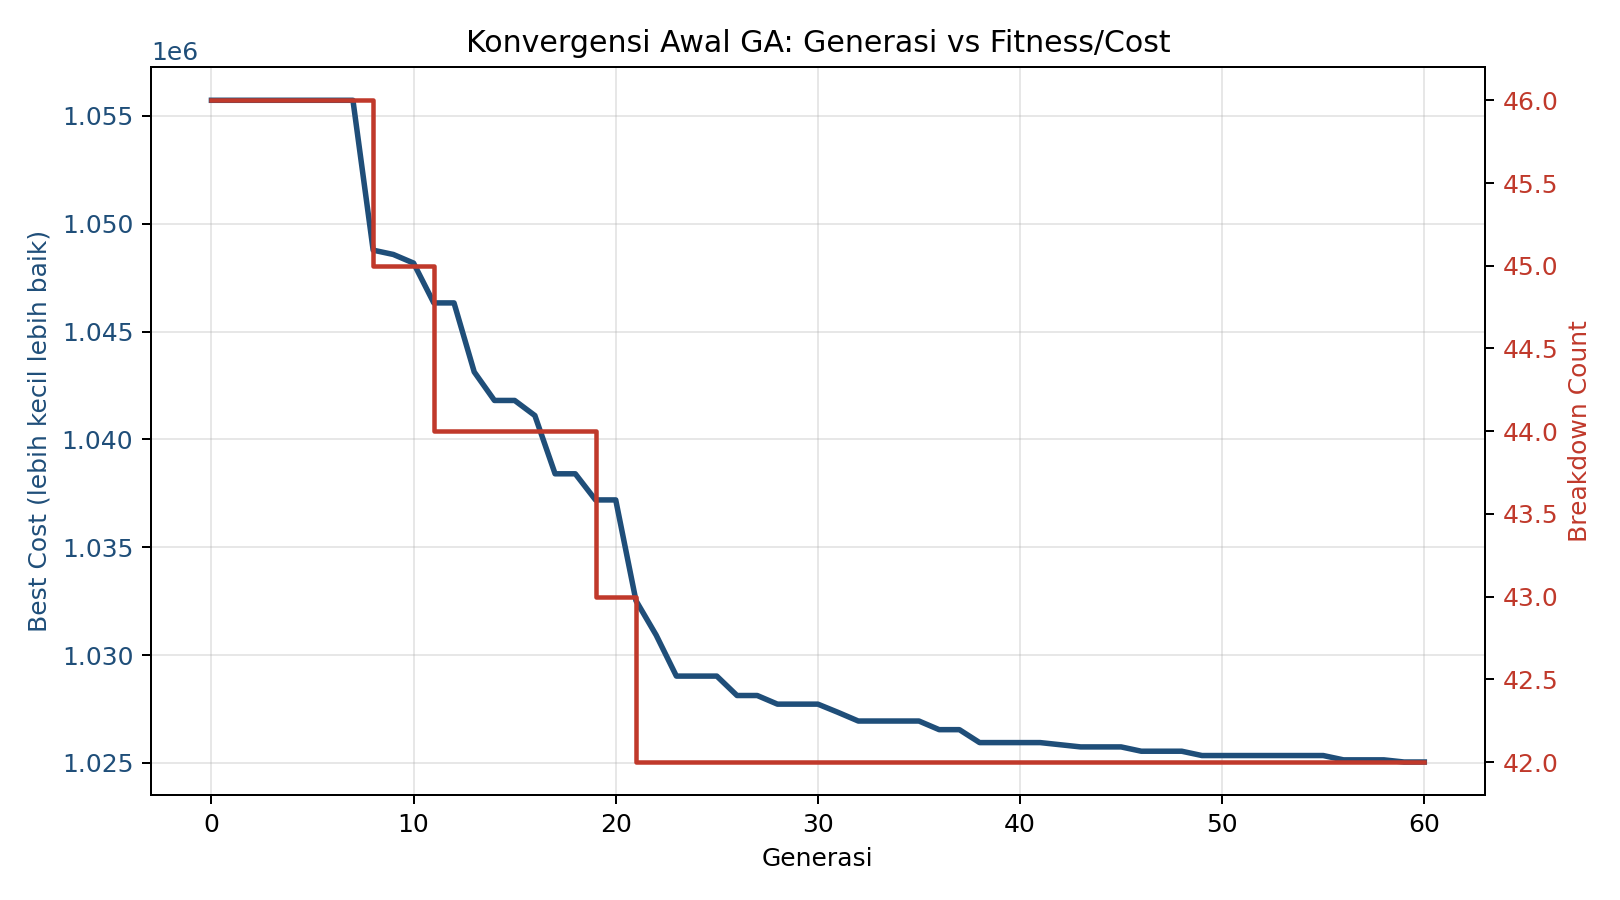

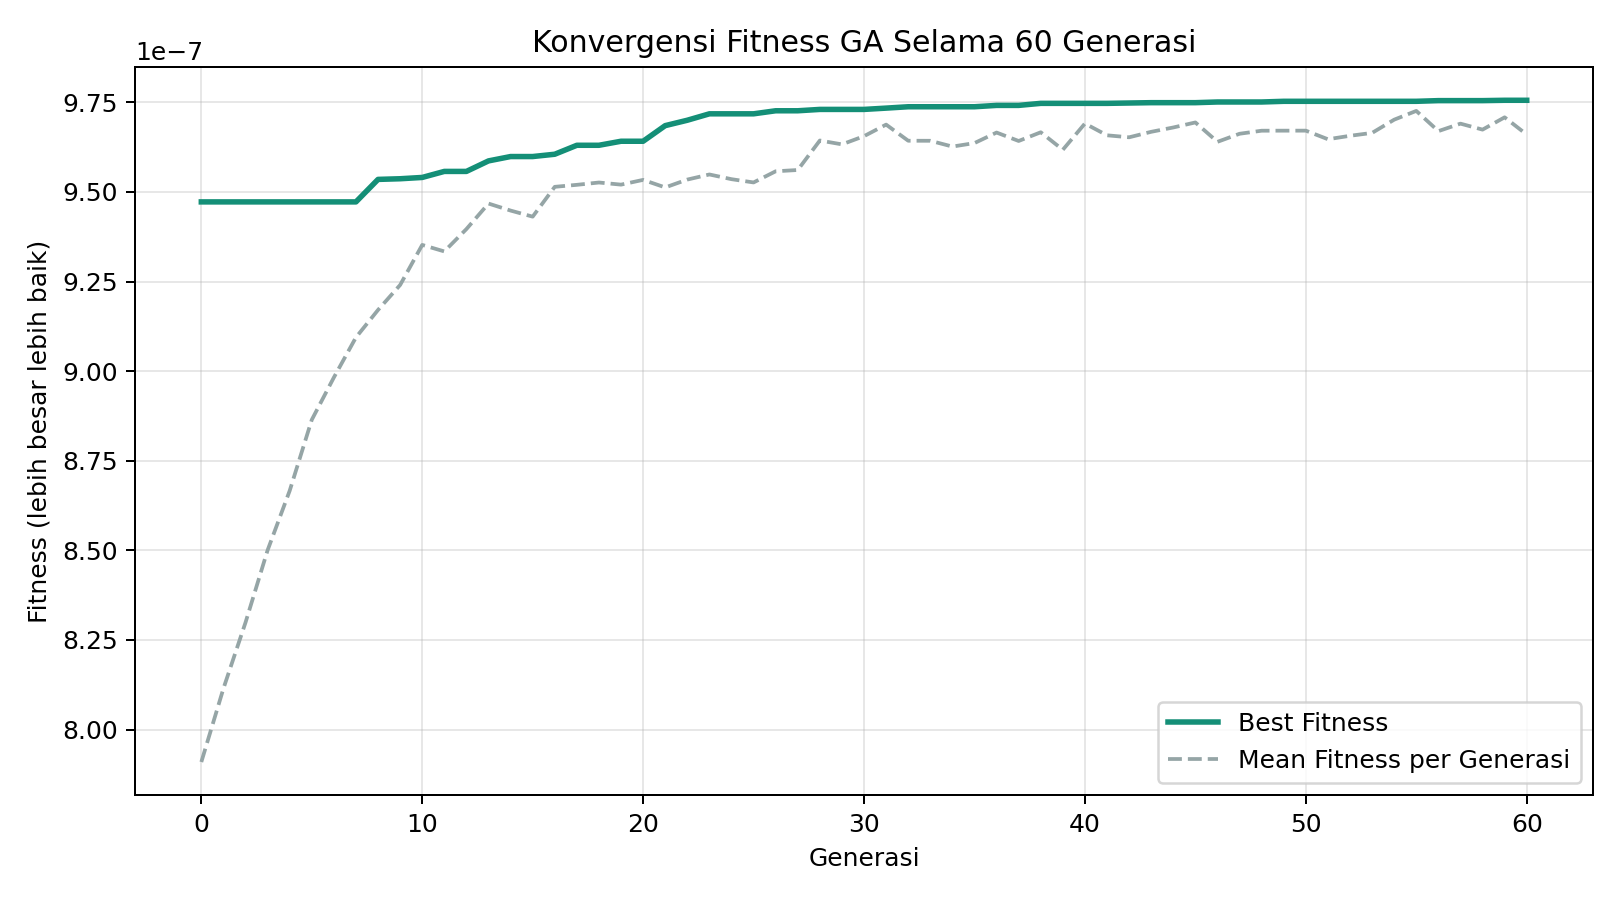

In [5]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

display(Image(filename=str(TAHAP_3 / 'outputs' / 'plots' / 'tahap3_ga_convergence.png')))
display(Image(filename=str(TAHAP_3 / 'outputs' / 'plots' / 'tahap3_ga_fitness_curve.png')))

Grafik konvergensi memperlihatkan perubahan hasil Algoritma Genetika dari generasi ke generasi. Cost yang menurun menunjukkan jadwal semakin baik. Fitness yang naik menunjukkan solusi semakin mendekati tujuan, yaitu mengurangi breakdown dan keterlambatan.

## 4. Jadwal Terbaik Algoritma Genetika

In [6]:
best_schedule = pd.read_csv(TAHAP_3 / 'outputs' / 'data' / 'tahap3_best_schedule_ga.csv')
best_schedule.head(15)

,urutan,machine_code,id_log_sensor,jenis_mesin,rul_ga_jam,durasi_perbaikan_jam,mulai_jam,selesai_jam,breakdown_saat_menunggu,keterlambatan_jam
0,1,M30,LOG-03721,CNC_Milling,0.00,2,0.0,2.0,0,0.00
1,2,M46,LOG-06138,Conveyor_Belt,0.00,3,2.0,5.0,1,2.00
2,3,M23,LOG-03107,Robot_Arm,23.03,3,5.0,8.0,0,0.00
3,4,M01,LOG-00016,CNC_Milling,17.05,3,8.0,11.0,0,0.00
4,5,M14,LOG-01447,Robot_Arm,23.64,4,11.0,15.0,0,0.00
5,6,M37,LOG-04444,CNC_Milling,15.83,6,15.0,21.0,0,0.00
6,7,M31,LOG-03899,CNC_Milling,24.51,4,21.0,25.0,0,0.00
7,8,M47,LOG-06325,Robot_Arm,27.54,5,25.0,30.0,0,0.00
8,9,M03,LOG-00388,Robot_Arm,31.32,6,30.0,36.0,0,0.00
9,10,M11,LOG-01255,Conveyor_Belt,0.00,2,36.0,38.0,1,36.00


Tabel jadwal terbaik menampilkan urutan awal mesin yang dikerjakan teknisi. Kolom `mulai_jam` dan `selesai_jam` menunjukkan waktu pengerjaan, sedangkan `breakdown_saat_menunggu` menunjukkan apakah mesin sudah terlambat ditangani. Dari tabel ini urutan jadwal bisa dibaca sebagai rencana kerja teknisi.

## Kesimpulan Tahap 3

Integrasi Machine Learning dan Algoritma Genetika berhasil berjalan. Model menerima data 50 mesin dengan 7 fitur, lalu menghasilkan 50 prediksi sisa umur. Algoritma Genetika menggunakan hasil prediksi tersebut untuk mencari urutan perbaikan selama 60 generasi.